# Рельеф: сколько считает и насколько точно

Замер `sima-relief-service` на 123 листах датасета `test_data/dsm_dataset`
(ОФП + ВЛС + ранее посчитанная эталонная ЦМР на каждый лист).

**Отвечает на два вопроса заказчика:** уложится ли расчёт в приемлемое время на
производственном объёме и какую точность ЦМР даёт конвейер.

Структура: часть I — время (разделы 5–8), часть II — точность (9–10),
визуальный контроль (11), итог одной таблицей (13).

### Как читать числа точности

Отклонение от эталона считается **раздельно по двум множествам ячеек**, и это
принципиально: они измеряют разные вещи.

| | Что это | Что характеризует |
|---|---|---|
| **по измеренным** | ячейки, значение которых получено растеризацией точек | точность построения рельефа |
| **по всем** | плюс ячейки, достроенные заполнением пустот | точность построения + цена интерполяции |

Маску измеренных ячеек сервис сохраняет сам, сразу после растеризации и до
любого заполнения (`ReliefService(save_measured_mask=True)`) — по готовому растру
отличить измеренную ячейку от достроенной уже нельзя.

### Ограничение методологии

ВЛС датасета хранит **ТЛО** — нормализованные высоты, а не абсолютные отметки.
Чтобы построение ЦМР вообще стало возможным, абсолютные Z восстанавливаются
**по эталонной ЦМР** (`relief_bench.restore_absolute`).

Поэтому сравнение с эталоном — **не независимая валидация точности съёмки**.
Оно измеряет, сколько сервис теряет на круге «эталон → точки → эталон»: цепочку
SMRF → растеризация → заполнение пустот → сглаживание. Это нижняя граница
ошибки; на реальных абсолютных ВЛС к ней добавится ошибка самих измерений.

Для полноценной валидации нужны ВЛС с абсолютными Z либо контрольные точки GNSS.
У ЦММ эталона в датасете нет вовсе — для неё считается не ошибка, а разность
`ЦММ − ЦМР`, то есть высота объектов над землёй.


## 1. Настройка

In [1]:
import json, os, sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Пути не зашиты: каталог запуска, либо переменные окружения.
BACKEND = Path(os.environ.get('SIMA_BACKEND', Path.cwd())).resolve()
if not (BACKEND / 'benchmarks').is_dir():
    raise RuntimeError(f'Не найден каталог benchmarks в {BACKEND}; задайте SIMA_BACKEND')

sys.path.insert(0, str(BACKEND / 'benchmarks'))
import relief_bench as RB

DATASET_ROOT = os.environ.get('SIMA_DSM_DATASET', RB.DEFAULT_DATASET_ROOT)
RESULTS_DIR = BACKEND / 'benchmarks' / 'results'
RESULTS_PATH = RESULTS_DIR / 'results.jsonl'

# Перезапуск полного прогона (≈25 мин на 123 листа). False — читать готовый JSONL.
RUN_BENCHMARK = False
LIMIT = None            # ограничить число листов при перезапуске

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110

print(f'relief_bench: {RB.__file__}')
print(f'датасет:      {DATASET_ROOT}')
print(f'результаты:   {RESULTS_PATH}')


relief_bench: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/relief_bench.py
датасет:      /Users/sergeyzay/Documents/НЕДРА/СИМА/test_data/dsm_dataset
результаты:   /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results/results.jsonl


## 2. Отбор триплетов

Пересечение по стему ОФП: `OFP ∩ LAS ∩ DSM`.

In [2]:
triplets = RB.find_triplets(DATASET_ROOT)

n_ofp = len(list((Path(DATASET_ROOT) / 'OFP').glob('*.tif')))
n_las = len(list((Path(DATASET_ROOT) / 'LAS').glob('*.las')))
n_dsm = len(list((Path(DATASET_ROOT) / 'DSM').rglob('*.tif')))

print(f'ОФП файлов:        {n_ofp}')
print(f'ВЛС файлов:        {n_las}')
print(f'Эталонов ЦМР:      {n_dsm}')
print(f'Полных триплетов:  {len(triplets)}')
print()
pd.DataFrame([{'name': t.name,
               'OFP': Path(t.ofp).name,
               'LAS': Path(t.las).name,
               'ЭТАЛОН': str(Path(t.ref).relative_to(DATASET_ROOT))}
              for t in triplets]).head(10)

ОФП файлов:        354
ВЛС файлов:        132
Эталонов ЦМР:      370
Полных триплетов:  123



,name,OFP,LAS,ЭТАЛОН
0,P-42-041-239-e,P-42-041-239-e.tif,P-42-041-239-e_ground_TLO.las,DSM/246/P-42-041-239-e.tif
1,P-42-041-239-f,P-42-041-239-f.tif,P-42-041-239-f_ground_TLO.las,DSM/246/P-42-041-239-f.tif
2,P-42-041-239-g,P-42-041-239-g.tif,P-42-041-239-g_ground_TLO.las,DSM/246/P-42-041-239-g.tif
3,P-42-041-239-h,P-42-041-239-h.tif,P-42-041-239-h_ground_TLO.las,DSM/246/P-42-041-239-h.tif
4,P-42-041-240-d,P-42-041-240-d.tif,P-42-041-240-d_ground_TLO.las,DSM/245/P-42-041-240-d.tif
5,P-42-041-240-e,P-42-041-240-e.tif,P-42-041-240-e_ground_TLO.las,DSM/245/P-42-041-240-e.tif
6,P-42-041-240-f,P-42-041-240-f.tif,P-42-041-240-f_ground_TLO.las,DSM/245/P-42-041-240-f.tif
7,P-42-041-256-i,P-42-041-256-i.tif,P-42-041-256-i_ground_TLO.las,DSM/240/P-42-041-256-i.tif
8,P-42-042-225-d,P-42-042-225-d.tif,P-42-042-225-d_ground_TLO.las,DSM/239/P-42-042-225-d.tif
9,P-42-042-225-e,P-42-042-225-e.tif,P-42-042-225-e_ground_TLO.las,DSM/239/P-42-042-225-e.tif


## 3. Параметры расчёта

Идентичны `relief_demo.ipynb` и легаси-прототипу, чтобы бенчмарк мерил
именно production-конфигурацию:

| Блок | Значения |
|---|---|
| Классификация ground | SMRF: `slope=0.2, window=16, threshold=0.45, scalar=1.2` |
| Растеризация ЦМР | IDW, разрешение 1.0 м, заполнение дыр `max_search_distance=100`, `edge_extrapolation_m=5` |
| ЦММ | `output_type='max'`, интерполяция + заполнение дыр |
| Сглаживание | Гаусс `sigma=2.0 × res`, `window=5` |
| Производные | уклон, экспозиция, TPI `radii=[270, 810, 2430]` м |
| Векторы | горизонтали 0.5 / 2 / 5 / 10 м, TIN (.dxf) |
| Отметки высот | из ground-LAS, минимальное расстояние между точками 10 м |
| Детерминизм | `deterministic=True, seed=42` |

СК берётся из эталонного растра (SK-42 / Transverse Mercator, зона по 66.05°E).

In [3]:
import inspect
print(inspect.getsource(RB.default_params))

def default_params(crs_wkt: str, resolution: float = 1.0) -> ReliefParams:
    """Параметры Q3, выровненные с легаси-прототипом и relief_demo.ipynb."""
    return ReliefParams(
        target_crs=crs_wkt,
        filter_method="smrf",
        smrf=SmrfParams(slope=0.2, window=16, threshold=0.45, scalar=1.2),
        smoothing=SmoothingParams(enabled=True, sigma=2.0, order=0, window=5),
        dsm=DsmParams(enabled=True, output_type="max", interpolate=True, fill_holes=True),
        derivatives=DerivativesParams(
            slopes=True, slopes_res=resolution,
            aspect=True, aspect_res=resolution,
            tpi=True, tpi_radii=[270, 810, 2430],
            interpolation=True, inter_amp=100,
            edge_extrapolation_m=5.0,
        ),
        vectors=VectorsParams(horizontals=[0.5, 2.0, 5.0, 10.0], tin=True),
        heights=HeightsParams(enabled=True, source="las", min_distance_m=10.0),
        deterministic=True, seed=42,
    )



## 4. Прогон бенчмарка

In [4]:
if RUN_BENCHMARK:
    records = RB.run_benchmark(DATASET_ROOT, str(RESULTS_DIR), limit=LIMIT,
                               results_path=str(RESULTS_PATH))
else:
    records = RB.load_results(str(RESULTS_PATH))

ok = [r for r in records if r['status'] == 'done']
bad = [r for r in records if r['status'] != 'done']
print(f'Обработано тайлов: {len(records)}   успешно: {len(ok)}   с ошибкой: {len(bad)}')
for r in bad:
    print(f"  ✗ {r['name']}: {r['reason']}")

Обработано тайлов: 123   успешно: 123   с ошибкой: 0


### 4.1. Сводная таблица по тайлам

In [5]:
def tile_row(r):
    dtm = (r.get('accuracy') or {}).get('dtm', {})
    allc = dtm.get('all_cells', {})
    row = {
        'tile': r['name'],
        'points': r.get('n_points'),
        'area_km2': r.get('ref_area_km2'),
        'las_MB': round(r.get('las_size_mb', 0), 1),
        'ofp_MB': round(r.get('ofp_size_mb', 0), 1),
        'density_pts_m2': r.get('las_points_density'),
        'tile_s': (r.get('tile_duration_ms') or 0) / 1000,
        'total_s': r.get('total_wall_ms', 0) / 1000,
        # точность по измеренным ячейкам — основная метрика
        'rmse_m': dtm.get('rmse'),
        'mae_m': dtm.get('mae'),
        'me_m': dtm.get('me'),
        'nmad_m': dtm.get('nmad'),
        'p95_m': dtm.get('p95'),
        'измерено_%': dtm.get('coverage_pct'),
        # то же со всеми ячейками, включая достроенные интерполяцией
        'rmse_всё_m': allc.get('rmse'),
        'полнота_%': allc.get('coverage_pct'),
        'rel_rmse_%': dtm.get('rel_rmse_pct'),
    }
    for s in RB.STEP_ORDER:
        row[f'ms_{s}'] = (r.get('steps', {}).get(s) or {}).get('ms')
    for k in ('assess_ms', 'restore_ms', 'metrics_ms'):
        row[k] = r.get('prep', {}).get(k)
    return row

df = pd.DataFrame([tile_row(r) for r in ok]).set_index('tile')
print(f'{len(df)} листов')
df[['points', 'area_km2', 'las_MB', 'density_pts_m2', 'tile_s',
    'rmse_m', 'rmse_всё_m', 'измерено_%', 'полнота_%']].head(15).round(3)


123 листов


,points,area_km2,las_MB,density_pts_m2,tile_s,rmse_m,rmse_всё_m,измерено_%,полнота_%
tile,,,,,,,,,
P-42-041-239-e,87500,0.446,3.0,2.112,1.643,0.056,0.084,28.055,87.944
P-42-041-239-f,93220,0.446,3.2,2.127,1.527,0.061,0.082,27.537,87.838
P-42-041-239-g,1357824,0.446,46.2,3.048,17.659,0.065,0.379,27.839,95.393
P-42-041-239-h,1166858,0.446,39.7,2.618,14.877,0.060,0.083,32.795,95.301
P-42-041-240-d,85211,0.446,2.9,1.842,1.347,0.059,0.076,35.431,88.472
P-42-041-240-e,79011,0.446,2.7,1.631,1.270,0.057,0.072,40.273,88.853
P-42-041-240-f,83361,0.446,2.8,1.639,1.358,0.058,0.074,38.110,90.168
P-42-041-256-i,955826,0.447,32.5,2.141,10.972,0.074,0.150,16.915,94.946
P-42-042-225-d,95842,0.446,3.3,1.804,1.457,0.056,0.071,39.243,89.411


---
# ЧАСТЬ I. ВРЕМЯ

## 5. Время на тайл

In [6]:
t = df['tile_s']
summary = pd.DataFrame({
    'Время конвейера на тайл, с': [
        t.min(), t.quantile(.25), t.median(), t.mean(), t.quantile(.75),
        t.quantile(.95), t.max(), t.sum(),
    ]}, index=['min', 'p25', 'median', 'mean', 'p75', 'p95', 'max', 'СУММА']).round(2)

thr = pd.DataFrame({
    'Пропускная способность': [
        df['points'].sum() / t.sum() / 1e6,
        df['area_km2'].sum() / t.sum() * 3600,
        t.sum() / df['area_km2'].sum(),
        t.sum() / (df['points'].sum() / 1e6),
    ]}, index=['млн точек / с', 'км² / час', 'с на км²', 'с на млн точек']).round(2)

display(summary, thr)
print(f"Всего обработано: {df['points'].sum()/1e6:.1f} млн точек, "
      f"{df['area_km2'].sum():.2f} км², {df['las_MB'].sum()/1024:.2f} ГБ LAS")
print(f"Суммарное время конвейера: {t.sum()/60:.1f} мин "
      f"(вкл. подготовку и метрики: {df['total_s'].sum()/60:.1f} мин)")

,"Время конвейера на тайл, с"
min,1.05
p25,3.41
median,9.58
mean,20.72
p75,11.38
p95,15.34
max,657.84
СУММА,2548.55


,Пропускная способность
млн точек / с,0.03
км² / час,77.97
с на км²,46.17
с на млн точек,32.79


Всего обработано: 77.7 млн точек, 55.19 км², 2.58 ГБ LAS
Суммарное время конвейера: 42.5 мин (вкл. подготовку и метрики: 18.2 мин)


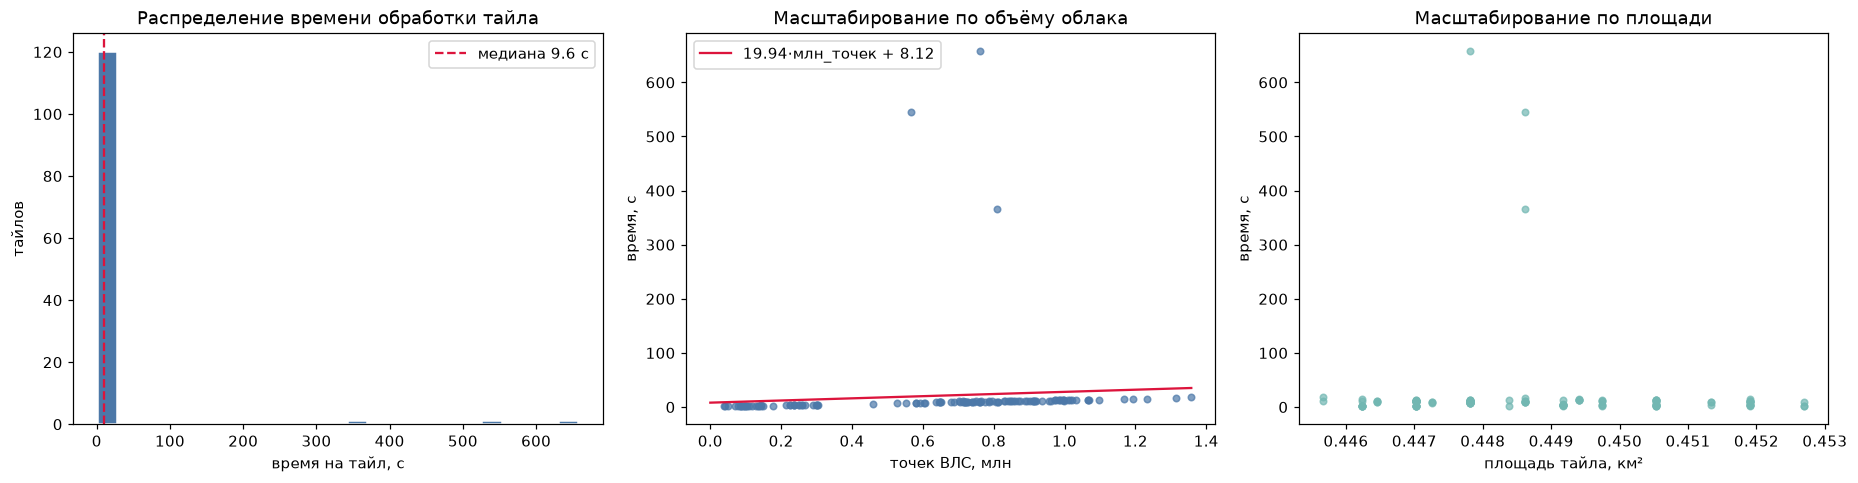

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(t, bins=25, color='#4C78A8', edgecolor='white')
axes[0].axvline(t.median(), color='crimson', ls='--', label=f'медиана {t.median():.1f} с')
axes[0].set_xlabel('время на тайл, с'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Распределение времени обработки тайла'); axes[0].legend()

axes[1].scatter(df['points'] / 1e6, t, s=18, alpha=.7, color='#4C78A8')
k = np.polyfit(df['points'] / 1e6, t, 1)
xs = np.linspace(0, (df['points'] / 1e6).max(), 50)
axes[1].plot(xs, np.polyval(k, xs), color='crimson', lw=1.5,
             label=f'{k[0]:.2f}·млн_точек + {k[1]:.2f}')
axes[1].set_xlabel('точек ВЛС, млн'); axes[1].set_ylabel('время, с')
axes[1].set_title('Масштабирование по объёму облака'); axes[1].legend()

axes[2].scatter(df['area_km2'], t, s=18, alpha=.7, color='#72B7B2')
axes[2].set_xlabel('площадь тайла, км²'); axes[2].set_ylabel('время, с')
axes[2].set_title('Масштабирование по площади')

plt.tight_layout(); plt.show()

## 6. Время по шагам конвейера

In [8]:
step_cols = [f'ms_{s}' for s in RB.STEP_ORDER]
steps = df[step_cols].rename(columns=lambda c: c[3:])

step_summary = pd.DataFrame({
    'сумма, с': steps.sum() / 1000,
    'доля, %': 100 * steps.sum() / steps.sum().sum(),
    'медиана, мс': steps.median(),
    'среднее, мс': steps.mean(),
    'p95, мс': steps.quantile(.95),
    'max, мс': steps.max(),
}).sort_values('доля, %', ascending=False).round(2)
step_summary

,"сумма, с","доля, %","медиана, мс","среднее, мс","p95, мс","max, мс"
dsm,1921.44,75.51,3572.0,15621.46,6394.8,651226
dtm,567.14,22.29,5479.0,4610.88,7531.7,9504
tpi,9.03,0.35,75.0,73.43,81.0,87
tin,8.86,0.35,83.0,72.01,123.9,127
aspect,8.74,0.34,73.0,71.09,77.0,109
heights,8.52,0.33,76.0,69.30,121.0,137
slope,8.50,0.33,71.0,69.10,75.0,90
smooth,7.16,0.28,63.0,58.19,81.9,118
contours,5.37,0.21,42.0,43.67,75.6,246
crop,0.00,0.00,0.0,0.00,0.0,0


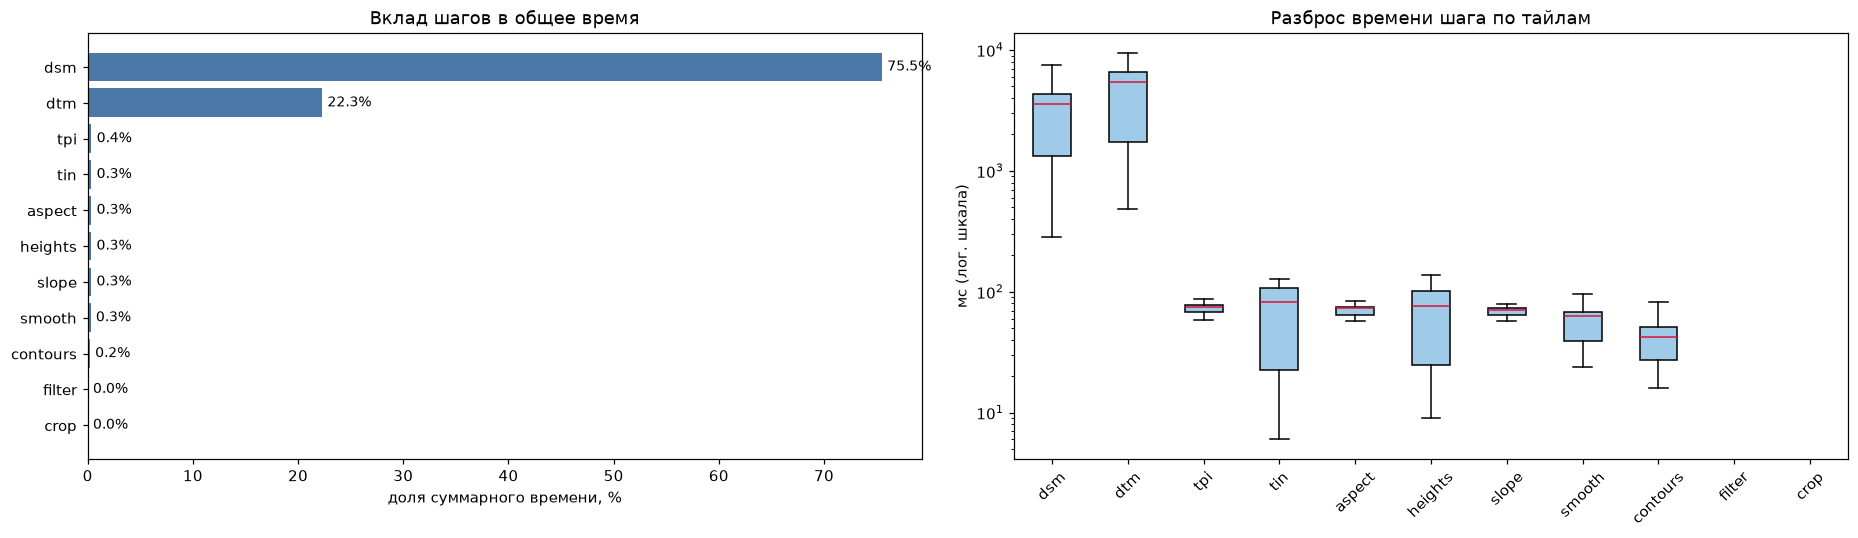

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

share = (steps.sum() / steps.sum().sum() * 100).sort_values()
axes[0].barh(share.index, share.values, color='#4C78A8')
for i, v in enumerate(share.values):
    axes[0].text(v + .5, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('доля суммарного времени, %')
axes[0].set_title('Вклад шагов в общее время')

order = share.index[::-1]
axes[1].boxplot([steps[c].dropna() for c in order], tick_labels=list(order),
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#A0CBE8'), medianprops=dict(color='crimson'))
axes[1].set_yscale('log'); axes[1].set_ylabel('мс (лог. шкала)')
axes[1].set_title('Разброс времени шага по тайлам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

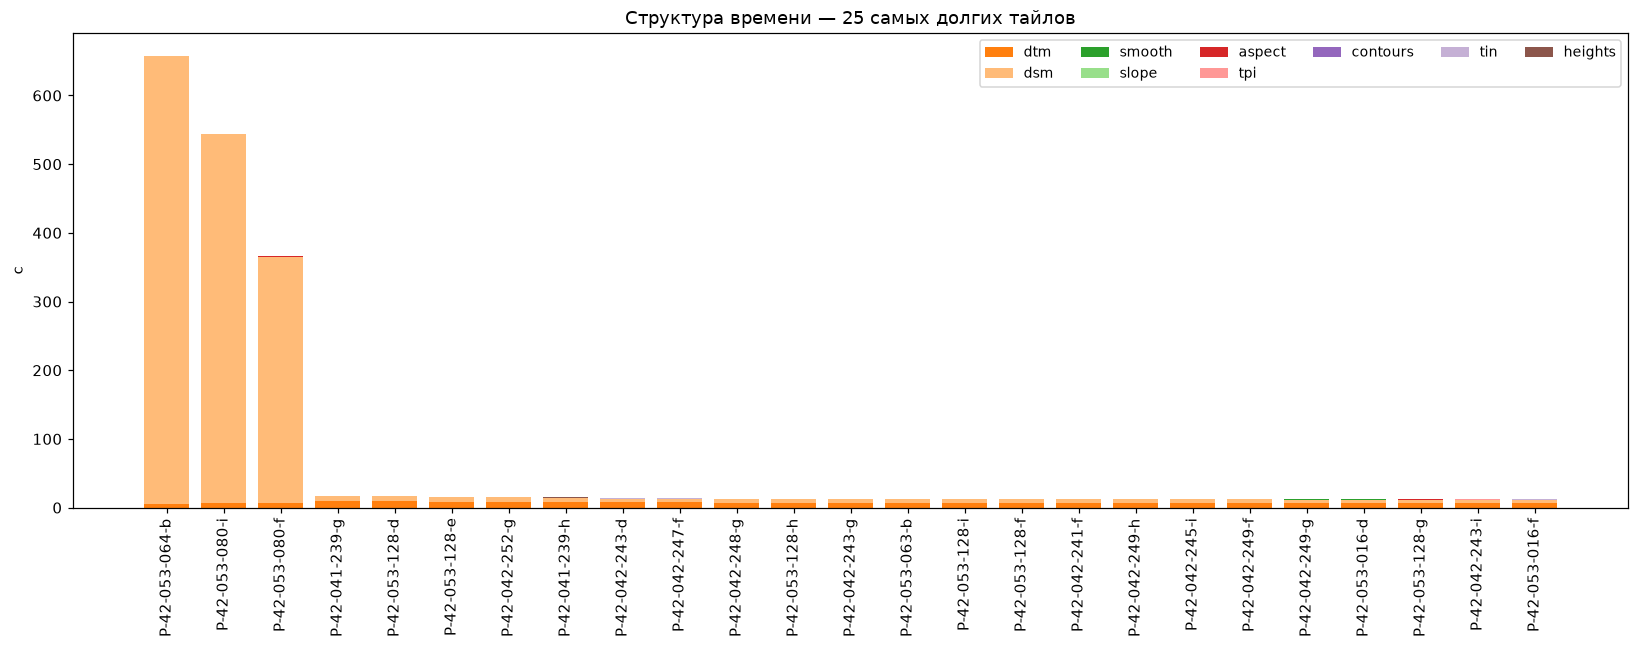

In [10]:
# Стек по 25 самым тяжёлым тайлам
top = df.nlargest(25, 'tile_s')
sub = top[step_cols].rename(columns=lambda c: c[3:]).fillna(0) / 1000

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(sub))
cmap = plt.get_cmap('tab20')
for i, c in enumerate(RB.STEP_ORDER):
    if c in sub and sub[c].sum() > 0:
        ax.bar(sub.index, sub[c], bottom=bottom, label=c, color=cmap(i % 20))
        bottom += sub[c].values
ax.set_ylabel('с'); ax.set_title('Структура времени — 25 самых долгих тайлов')
ax.tick_params(axis='x', rotation=90)
ax.legend(ncol=6, fontsize=9)
plt.tight_layout(); plt.show()

## 7. Время и размер по каждому выходному результату

Каждый артефакт привязан к породившему его шагу. `dtm` и `ground_las` выходят из
одного шага `dtm`; четыре шейпфайла горизонталей — из одного шага `contours`
(посечённая разбивка — в п. 7.1).

In [11]:
rows = []
for r in ok:
    for a in r.get('artifacts', []):
        rows.append({'tile': r['name'], 'layer': a['layer'], 'kind': a['kind'],
                     'file': a['file'], 'step': a['step'],
                     'ms': a['step_ms'], 'size_kb': (a['size_bytes'] or 0) / 1024})
arts = pd.DataFrame(rows)

# Размеры считаются по файлам, время — по уникальным парам (тайл, шаг):
# шаг `dtm` отдаёт два артефакта, `contours` — четыре, и наивное суммирование
# по файлам умножило бы их время на число файлов.
size_agg = arts.groupby('layer').agg(
    файлов=('file', 'count'),
    формат=('kind', 'first'),
    шаг=('step', 'first'),
    медиана_KB=('size_kb', 'median'),
    сумма_MB=('size_kb', lambda s: s.sum() / 1024),
)
time_agg = (arts.drop_duplicates(subset=['tile', 'step'])
            .groupby('step')['ms']
            .agg(медиана_мс='median', среднее_мс='mean',
                 p95_мс=lambda s: s.quantile(.95),
                 сумма_с=lambda s: s.sum() / 1000))

by_layer = (size_agg.join(time_agg, on='шаг')
            .sort_values('сумма_с', ascending=False).round(2))
by_layer['примечание'] = np.where(
    by_layer.groupby('шаг')['шаг'].transform('size') > 1,
    'время делится с др. слоями того же шага', '')
by_layer

,файлов,формат,шаг,медиана_KB,сумма_MB,медиана_мс,среднее_мс,p95_мс,сумма_с,примечание
layer,,,,,,,,,,
dsm,123,geotiff,dsm,1750.64,161.36,3572.0,15621.46,6394.8,1921.44,
dtm,123,geotiff,dtm,1745.34,160.70,5479.0,4610.88,7531.7,567.14,время делится с др. слоями того же шага
dtm_measured,123,geotiff,dtm,437.43,40.29,5479.0,4610.88,7531.7,567.14,время делится с др. слоями того же шага
ground_las,123,las,dtm,25420.32,2668.49,5479.0,4610.88,7531.7,567.14,время делится с др. слоями того же шага
tpi,123,geotiff,tpi,18.67,1.76,75.0,73.43,81.0,9.03,
tin,123,dxf,tin,760.11,69.27,83.0,72.01,123.9,8.86,
aspect,123,geotiff,aspect,1745.34,160.70,73.0,71.09,77.0,8.74,
heights,123,shp,heights,77.76,7.12,76.0,69.30,121.0,8.52,
slope,123,geotiff,slope,1745.34,160.70,71.0,69.10,75.0,8.50,


### 7.2. Самые крупные артефакты

`ground_las` (LAS отфильтрованных ground-точек) — крупнейший по объёму выход:
он сохраняется как промежуточный вход для TIN и отметок высот. Если он не нужен
потребителю, `save_ground_las=False` в `step_dtm` убирает ~2.6 ГБ на 123 тайлах
без влияния на остальные артефакты.

In [12]:
tot = by_layer['сумма_MB'].sum()
disk = by_layer[['формат', 'файлов', 'медиана_KB', 'сумма_MB']].copy()
disk['доля объёма, %'] = (100 * disk['сумма_MB'] / tot).round(1)
display(disk.sort_values('сумма_MB', ascending=False).round(2))
print(f'Итого артефактов: {int(disk["файлов"].sum())} файлов, {tot/1024:.2f} ГБ '
      f'на {len(df)} тайлов ({tot/len(df):.0f} МБ на тайл)')

,формат,файлов,медиана_KB,сумма_MB,"доля объёма, %"
layer,,,,,
ground_las,las,123,25420.32,2668.49,70.7
contours,shp,492,150.70,184.47,4.9
dsm,geotiff,123,1750.64,161.36,4.3
dtm,geotiff,123,1745.34,160.70,4.3
aspect,geotiff,123,1745.34,160.70,4.3
slope,geotiff,123,1745.34,160.70,4.3
dtm_smooth,geotiff,123,1743.11,160.48,4.3
tin,dxf,123,760.11,69.27,1.8
dtm_measured,geotiff,123,437.43,40.29,1.1


Итого артефактов: 1722 файлов, 3.69 ГБ на 123 тайлов (31 МБ на тайл)


### 7.1. Горизонтали посечённо

In [13]:
crows = []
for r in ok:
    for interval, v in (r.get('contours_detail') or {}).items():
        crows.append({'tile': r['name'], 'сечение_м': float(interval),
                      'ms': v['ms'], 'size_kb': (v['size_bytes'] or 0) / 1024})
cdf = pd.DataFrame(crows)
if len(cdf):
    display(cdf.groupby('сечение_м').agg(
        тайлов=('tile', 'count'),
        медиана_мс=('ms', 'median'),
        среднее_мс=('ms', 'mean'),
        p95_мс=('ms', lambda s: s.quantile(.95)),
        медиана_KB=('size_kb', 'median'),
    ).round(2))
else:
    print('Посечённые замеры отсутствуют в результатах')

,тайлов,медиана_мс,среднее_мс,p95_мс,медиана_KB
сечение_м,,,,,
0.5,123,19.24,19.96,38.27,908.25
2.0,123,10.79,10.46,15.92,238.71
5.0,123,6.46,7.69,12.63,35.18
10.0,123,5.10,6.43,11.71,0.10


## 8. Накладные расходы вне сервиса

`assess` — оценка материалов ВЛС/АФС (Q3 «Оценка файлов»), входит в
production-путь. `restore` — восстановление абсолютных Z из ТЛО, **артефакт
методологии бенчмарка**, в production его не будет. `metrics` — расчёт метрик
точности, только для бенчмарка.

In [14]:
overhead = df[['assess_ms', 'restore_ms', 'metrics_ms']].rename(columns={
    'assess_ms': 'оценка материалов', 'restore_ms': 'восстановление Z (ТЛО→абс.)',
    'metrics_ms': 'расчёт метрик точности'})
pd.DataFrame({
    'медиана, мс': overhead.median(),
    'среднее, мс': overhead.mean(),
    'сумма, с': overhead.sum() / 1000,
    'к времени конвейера, %': 100 * overhead.sum() / df['tile_s'].sum() / 1000,
}).round(2)

,"медиана, мс","среднее, мс","сумма, с","к времени конвейера, %"
оценка материалов,43.54,43.67,5.37,0.21
восстановление Z (ТЛО→абс.),65.18,58.27,7.17,0.28
расчёт метрик точности,497.48,459.76,56.55,2.22


---
# ЧАСТЬ II. ТОЧНОСТЬ

## 9. ЦМР против эталона

Отклонение `Δ = ЦМР построенная − ЦМР эталонная`; построенный растр перепроецирован
на сетку эталона билинейно.

* **ME** — систематический сдвиг;
* **MAE / RMSE** — средняя и среднеквадратичная ошибка;
* **NMAD** = `1.4826 · median(|Δ − median Δ|)` — робастная σ, не чувствительна к выбросам;
* **P95** — 95-й перцентиль |Δ|;
* **измерено** — доля ячеек эталона, где значение получено растеризацией точек.

Ниже — та же выборка в двух срезах: только измеренные ячейки и все.


In [15]:
def acc_frame(layer):
    """Метрики слоя по тайлам. Срез all_cells разворачивается в колонки all_*."""
    rows = []
    for r in ok:
        a = (r.get('accuracy') or {}).get(layer)
        if not a:
            continue
        row = {'tile': r['name'], **{k: v for k, v in a.items() if k != 'all_cells'}}
        row.update({f'all_{k}': v for k, v in (a.get('all_cells') or {}).items()})
        rows.append(row)
    return pd.DataFrame(rows).set_index('tile') if rows else pd.DataFrame()

acc_dtm = acc_frame('dtm')
acc_smooth = acc_frame('dtm_smooth')
acc_dsm = acc_frame('dsm')

metrics = ['me', 'mae', 'rmse', 'nmad', 'p95', 'max_abs', 'coverage_pct']
labels = ['ME, м', 'MAE, м', 'RMSE, м', 'NMAD, м', 'P95, м', 'max|Δ|, м', 'ячеек, %']

compare = pd.DataFrame({
    'ЦМР, измеренные ячейки': acc_dtm[metrics].median(),
    'ЦМР, все ячейки': acc_dtm[[f'all_{m}' for m in metrics]].median().set_axis(metrics),
    'ЦМР сглаженная, измеренные': acc_smooth[metrics].median(),
}).T
compare.columns = labels
print(f'Медианы по {len(acc_dtm)} листам:')
display(compare.round(4))

spread = pd.DataFrame({
    'RMSE по измеренным, м': acc_dtm['rmse'].describe(percentiles=[.25, .5, .75, .95]),
    'RMSE по всем, м': acc_dtm['all_rmse'].describe(percentiles=[.25, .5, .75, .95]),
}).drop('count')
display(spread.round(4))

k = acc_dtm['all_rmse'].median() / acc_dtm['rmse'].median()
print(f'Заполнение пустот увеличивает медианный RMSE в {k:.1f} раза '
      f'и растягивает p95 с {acc_dtm["rmse"].quantile(.95):.3f} '
      f'до {acc_dtm["all_rmse"].quantile(.95):.3f} м.')


Медианы по 123 листам:


,"ME, м","MAE, м","RMSE, м","NMAD, м","P95, м","max|Δ|, м","ячеек, %"
"ЦМР, измеренные ячейки",-0.0001,0.0448,0.0693,0.0397,0.1522,0.5466,19.9335
"ЦМР, все ячейки",-0.0019,0.0795,0.1132,0.0833,0.2359,0.9714,94.2196
"ЦМР сглаженная, измеренные",-0.0086,0.0674,0.0865,0.0796,0.1668,0.5301,19.9335


,"RMSE по измеренным, м","RMSE по всем, м"
mean,0.0665,0.2121
std,0.0137,0.4118
min,0.0429,0.0525
25%,0.0558,0.0737
50%,0.0693,0.1132
75%,0.0782,0.2502
95%,0.0869,0.4953
max,0.0921,4.2938


Заполнение пустот увеличивает медианный RMSE в 1.6 раза и растягивает p95 с 0.087 до 0.495 м.


In [16]:
crit = 5.0  # приёмочный критерий проекта: отн. RMSE < 5 %
passed = (acc_dtm['rel_rmse_pct'] < crit).sum()
print(f'Критерий «отн. RMSE < {crit} %» по измеренным ячейкам: '
      f'{passed}/{len(acc_dtm)} листов, фактический максимум '
      f'{acc_dtm["rel_rmse_pct"].max():.4f} %')
print('\nХудшие листы по RMSE (измеренные ячейки):')
display(acc_dtm.nlargest(5, 'rmse')[['rmse', 'mae', 'me', 'nmad', 'p95',
                                     'coverage_pct', 'all_rmse']].round(4))


Критерий «отн. RMSE < 5.0 %» по измеренным ячейкам: 123/123 листов, фактический максимум 0.0975 %

Худшие листы по RMSE (измеренные ячейки):


,rmse,mae,me,nmad,p95,coverage_pct,all_rmse
tile,,,,,,,
P-42-042-248-a,0.0921,0.0605,0.0014,0.0547,0.2007,12.2538,0.2921
P-42-042-250-i,0.0908,0.0601,0.0004,0.0535,0.1973,11.8908,0.2864
P-42-042-249-h,0.0898,0.0596,-0.0027,0.0542,0.1934,14.3962,0.1415
P-42-053-128-d,0.0897,0.0556,-0.0019,0.0465,0.1892,20.4311,0.3025
P-42-042-247-i,0.0877,0.0576,0.0051,0.0515,0.1901,10.5939,0.3120


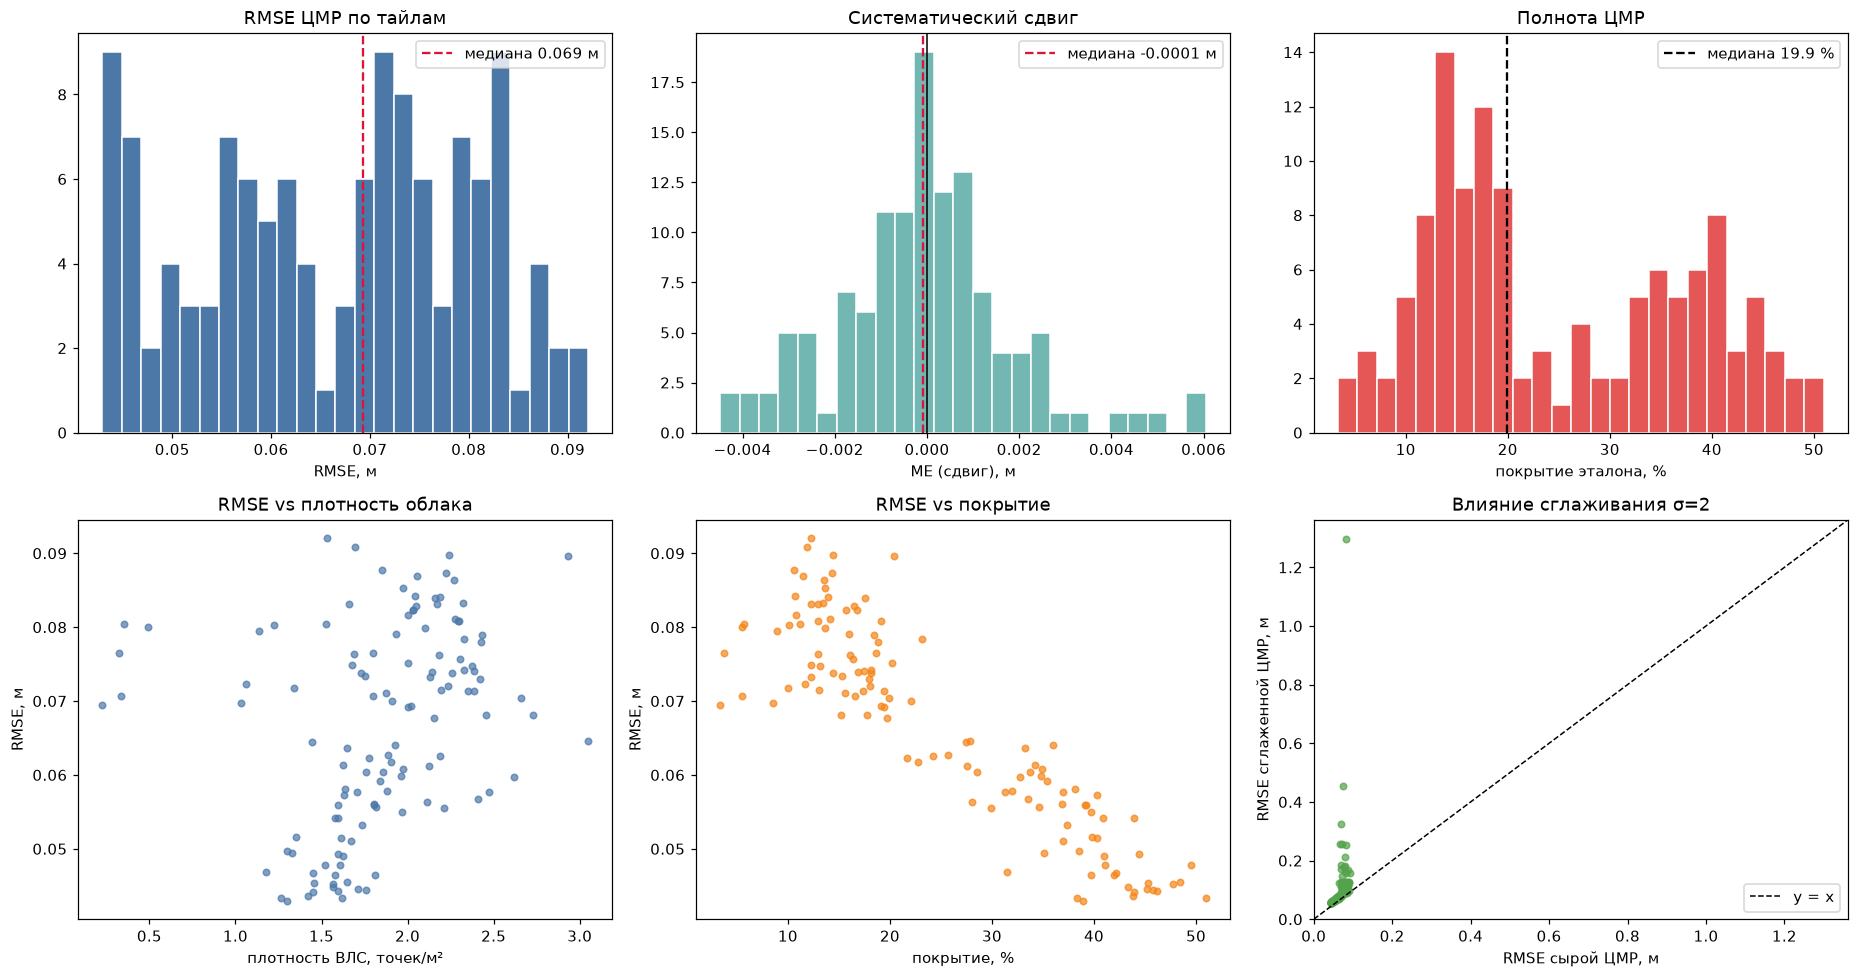

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

axes[0, 0].hist(acc_dtm['rmse'], bins=25, color='#4C78A8', edgecolor='white')
axes[0, 0].axvline(acc_dtm['rmse'].median(), color='crimson', ls='--',
                   label=f"медиана {acc_dtm['rmse'].median():.3f} м")
axes[0, 0].set_xlabel('RMSE, м'); axes[0, 0].set_title('RMSE ЦМР по тайлам'); axes[0, 0].legend()

axes[0, 1].hist(acc_dtm['me'], bins=25, color='#72B7B2', edgecolor='white')
axes[0, 1].axvline(0, color='k', lw=1)
axes[0, 1].axvline(acc_dtm['me'].median(), color='crimson', ls='--',
                   label=f"медиана {acc_dtm['me'].median():+.4f} м")
axes[0, 1].set_xlabel('ME (сдвиг), м'); axes[0, 1].set_title('Систематический сдвиг'); axes[0, 1].legend()

axes[0, 2].hist(acc_dtm['coverage_pct'], bins=25, color='#E45756', edgecolor='white')
axes[0, 2].axvline(acc_dtm['coverage_pct'].median(), color='k', ls='--',
                   label=f"медиана {acc_dtm['coverage_pct'].median():.1f} %")
axes[0, 2].set_xlabel('покрытие эталона, %'); axes[0, 2].set_title('Полнота ЦМР'); axes[0, 2].legend()

axes[1, 0].scatter(df.loc[acc_dtm.index, 'density_pts_m2'], acc_dtm['rmse'],
                   s=18, alpha=.7, color='#4C78A8')
axes[1, 0].set_xlabel('плотность ВЛС, точек/м²'); axes[1, 0].set_ylabel('RMSE, м')
axes[1, 0].set_title('RMSE vs плотность облака')

axes[1, 1].scatter(acc_dtm['coverage_pct'], acc_dtm['rmse'], s=18, alpha=.7, color='#F58518')
axes[1, 1].set_xlabel('покрытие, %'); axes[1, 1].set_ylabel('RMSE, м')
axes[1, 1].set_title('RMSE vs покрытие')

axes[1, 2].scatter(acc_dtm['rmse'], acc_smooth.loc[acc_dtm.index, 'rmse'],
                   s=18, alpha=.7, color='#54A24B')
lim = [0, max(acc_dtm['rmse'].max(), acc_smooth['rmse'].max()) * 1.05]
axes[1, 2].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[1, 2].set_xlim(lim); axes[1, 2].set_ylim(lim)
axes[1, 2].set_xlabel('RMSE сырой ЦМР, м'); axes[1, 2].set_ylabel('RMSE сглаженной ЦМР, м')
axes[1, 2].set_title('Влияние сглаживания σ=2'); axes[1, 2].legend()

plt.tight_layout(); plt.show()

### 9.1. Две разные «полноты» и откуда берётся низкая

После разделения метрик у слова «покрытие» два значения, и путать их нельзя.

**Доля измеренных ячеек** — какая часть листа опирается на реальные точки.
Ограничитель здесь не алгоритм, а сами данные: земля составляет медианно 12.3 %
точек облака, то есть около 0.20 ground-точки на м². На метровой сетке это одна
точка на пять ячеек, и пуассоновская оценка занятости даёт 18 % — ровно тот
порядок, что и наблюдается. Метровое разрешение здесь мельче, чем плотность
ground-точек позволяет: при 2 м/пиксель занятость поднялась бы до ~55 %, при 3 м —
до ~84 %.

Зависимость от плотности облака при этом обратная: чем гуще облако, тем **меньше**
измеренная часть ЦМР (17.5 % против 38.9 % на крайних третях датасета). Причина —
полог: плотное облако означает густой лес, сквозь который до земли доходит
меньшая доля импульсов.

**Полнота растра** — какая часть листа вообще получила значение, включая
достроенные ячейки. Здесь ограничитель другой: `writers.gdal` строит растр по
bbox облака ground-точек, и если облако не покрывает номенклатурный лист целиком,
недостающее не лечится интерполяцией — только сшивкой соседних листов с
перекрытием.

**Оговорка о знаменателе.** `coverage_pct` считается от валидных ячеек эталона, а
эталоны датасета неоднородны: часть листов покрыта полностью, часть — менее чем
на 20 % своей рамки. Сводная медиана смешивает два знаменателя, поэтому ниже
подмножества разделены.

Практический вывод: **полноту нужно контролировать отдельно от RMSE** — RMSE
считается по имеющимся ячейкам и её дефицит не показывает.


In [18]:
ref_full = pd.Series({r['name']: 100 * r['accuracy']['dtm']['n_ref_valid'] /
                      (r['ref_shape'][0] * r['ref_shape'][1]) for r in ok})
full = ref_full[ref_full >= 99].index
sparse = ref_full[ref_full < 20].index
print(f'Эталон полный (≥99 % рамки): {len(full)} листов;  '
      f'разреженный (<20 %): {len(sparse)};  прочие: {len(ok) - len(full) - len(sparse)}')

def by_sheet(idx, col):
    n = pd.Series({r['name']: (r['accuracy']['dtm'] if col == 'meas'
                               else r['accuracy']['dtm']['all_cells'])['n_valid'] for r in ok})
    tot = pd.Series({r['name']: r['ref_shape'][0] * r['ref_shape'][1] for r in ok})
    return (100 * n[idx] / tot[idx]).median()

display(pd.DataFrame({
    'листов': [len(full), len(sparse)],
    'измерено, % валидных ячеек эталона': [acc_dtm.loc[full, 'coverage_pct'].median(),
                                           acc_dtm.loc[sparse, 'coverage_pct'].median()],
    'измерено, % площади листа': [by_sheet(full, 'meas'), by_sheet(sparse, 'meas')],
    'полнота, % площади листа': [by_sheet(full, 'all'), by_sheet(sparse, 'all')],
}, index=['эталон полный', 'эталон разреженный']).round(1))
print('На разреженных листах сравнение идёт по узкой полосе эталона — '
      'с остальными эти проценты несопоставимы.')


Эталон полный (≥99 % рамки): 82 листов;  разреженный (<20 %): 14;  прочие: 27


,листов,"измерено, % валидных ячеек эталона","измерено, % площади листа","полнота, % площади листа"
эталон полный,82,22.4,22.4,95.1
эталон разреженный,14,36.8,3.9,9.6


На разреженных листах сравнение идёт по узкой полосе эталона — с остальными эти проценты несопоставимы.


,"измеренные ячейки, %","полнота растра, %"
mean,25.0,90.6
std,12.7,10.0
min,3.4,42.9
5%,9.0,67.1
25%,14.2,90.6
50%,19.9,94.2
75%,36.9,95.2
max,51.0,96.7


Листов с полнотой < 50 %: 3 из 123;  < 70 %: 8

Худшие по полноте растра:


,"плотность, т/м²","полнота, %","измерено, %","RMSE изм., м","RMSE всё, м"
tile,,,,,
P-42-042-247-d,0.492,42.933,5.533,0.080,0.485
P-42-042-247-h,0.323,44.103,3.712,0.076,0.293
P-42-042-247-g,0.227,45.412,3.368,0.069,0.291
P-42-042-247-e,1.031,57.883,8.573,0.070,0.304
P-42-042-249-e,1.338,62.482,10.031,0.072,0.318
P-42-042-249-b,0.354,63.264,5.668,0.080,0.259


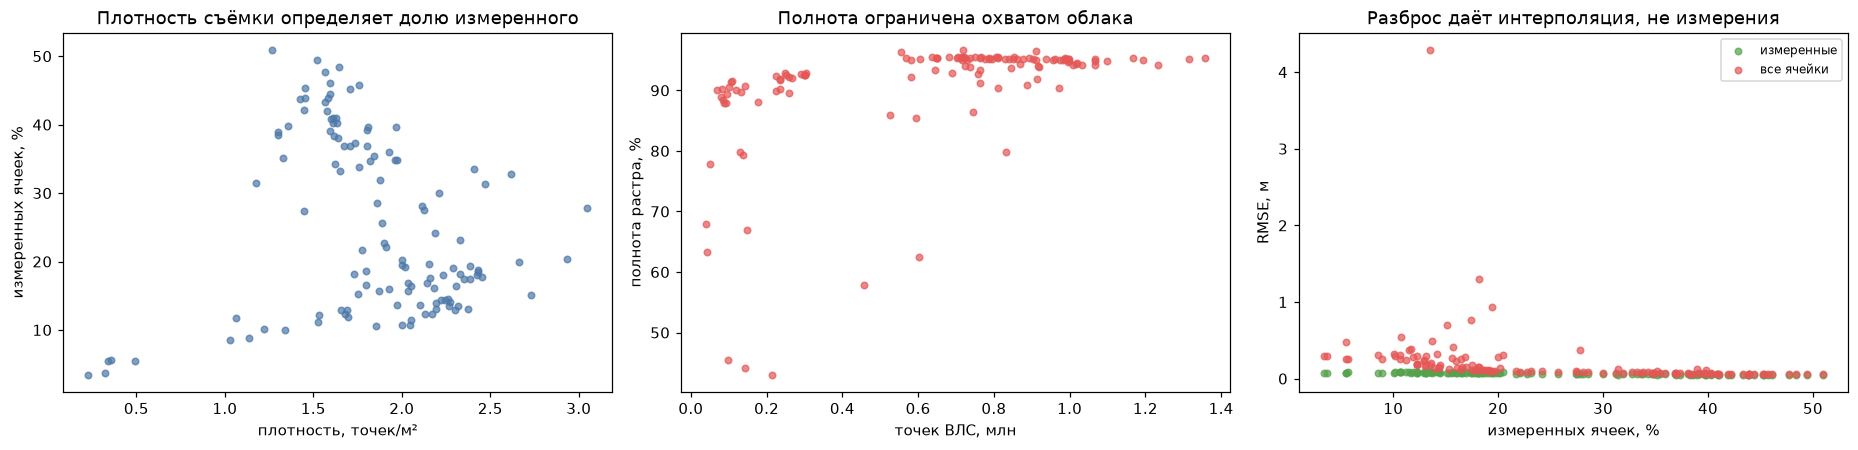

In [19]:
cov_m, cov_a = acc_dtm['coverage_pct'], acc_dtm['all_coverage_pct']
display(pd.DataFrame({
    'измеренные ячейки, %': cov_m.describe(percentiles=[.05, .25, .5, .75]),
    'полнота растра, %': cov_a.describe(percentiles=[.05, .25, .5, .75]),
}).drop('count').round(1))
print(f'Листов с полнотой < 50 %: {(cov_a < 50).sum()} из {len(cov_a)};  '
      f'< 70 %: {(cov_a < 70).sum()}')

print('\nХудшие по полноте растра:')
worst = acc_dtm.nsmallest(6, 'all_coverage_pct')[
    ['all_coverage_pct', 'coverage_pct', 'rmse', 'all_rmse']]
worst.insert(0, 'плотность_ВЛС', df.loc[worst.index, 'density_pts_m2'])
worst.columns = ['плотность, т/м²', 'полнота, %', 'измерено, %',
                 'RMSE изм., м', 'RMSE всё, м']
display(worst.round(3))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].scatter(df.loc[acc_dtm.index, 'density_pts_m2'], cov_m, s=18, alpha=.7, color='#4C78A8')
ax[0].set_xlabel('плотность, точек/м²'); ax[0].set_ylabel('измеренных ячеек, %')
ax[0].set_title('Плотность съёмки определяет долю измеренного')
ax[1].scatter(df.loc[acc_dtm.index, 'points'] / 1e6, cov_a, s=18, alpha=.7, color='#E45756')
ax[1].set_xlabel('точек ВЛС, млн'); ax[1].set_ylabel('полнота растра, %')
ax[1].set_title('Полнота ограничена охватом облака')
ax[2].scatter(cov_m, acc_dtm['rmse'], s=18, alpha=.7, color='#54A24B', label='измеренные')
ax[2].scatter(cov_m, acc_dtm['all_rmse'], s=18, alpha=.7, color='#E45756', label='все ячейки')
ax[2].set_xlabel('измеренных ячеек, %'); ax[2].set_ylabel('RMSE, м')
ax[2].set_title('Разброс даёт интерполяция, не измерения'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


### 9.2. Цена сглаживания

Гаусс (σ = 2 × разрешение) выполняется перед расчётом производных: уклон и
экспозиция считаются по сглаженному растру. Он подавляет шум растеризации и
одновременно срезает реальные формы рельефа, поэтому относительно эталона
ошибка закономерно растёт. Ниже — насколько именно.


In [20]:
cols = ['rmse', 'mae', 'nmad', 'p95', 'max_abs', 'z_std']
cmp_sm = pd.DataFrame({
    'сырая ЦМР': acc_dtm[cols].median(),
    'сглаженная ЦМР': acc_smooth[cols].median(),
})
cmp_sm['изменение, %'] = 100 * (cmp_sm['сглаженная ЦМР'] / cmp_sm['сырая ЦМР'] - 1)
cmp_sm.index = ['RMSE, м', 'MAE, м', 'NMAD, м', 'P95, м', 'max|Δ|, м', 'σ высот растра, м']
display(cmp_sm.round(4))
print('Метрики — по измеренным ячейкам: сглаживание сравнивается само с собой, '
      'без примеси заполнения пустот.')


,сырая ЦМР,сглаженная ЦМР,"изменение, %"
"RMSE, м",0.0693,0.0865,24.8751
"MAE, м",0.0448,0.0674,50.5579
"NMAD, м",0.0397,0.0796,100.4218
"P95, м",0.1522,0.1668,9.6459
"max|Δ|, м",0.5466,0.5301,-3.0275
"σ высот растра, м",0.4935,0.4733,-4.1073


Метрики — по измеренным ячейкам: сглаживание сравнивается само с собой, без примеси заполнения пустот.


## 10. ЦММ (DSM)

Эталона для ЦММ в датасете нет — ЦММ строится по всем точкам (`output_type='max'`),
эталон же представляет землю. Поэтому «ошибка ЦММ относительно эталона» —
это не ошибка, а **высота растительности и объектов над землёй**; она приводится
как описательная величина. Содержательный показатель — `ЦММ − ЦМР`.

In [21]:
hrows = []
for r in ok:
    h = (r.get('accuracy') or {}).get('dsm_minus_dtm')
    if h:
        hrows.append({'tile': r['name'], **h})
hdf = pd.DataFrame(hrows).set_index('tile')

display(pd.DataFrame({
    'ЦММ − ЦМР (высота объектов), м': [hdf['mean'].median(), hdf['p95'].median(), hdf['max'].median(),
                                       hdf['max'].max()],
    'ЦММ vs эталон (для справки), м': [acc_dsm['me'].median(), acc_dsm['p95'].median(),
                                       acc_dsm['max_abs'].median(), acc_dsm['max_abs'].max()],
}, index=['медиана среднего', 'медиана P95', 'медиана max', 'глобальный max']).round(3))

display(pd.DataFrame({
    'ЦММ': acc_dsm[['z_min', 'z_max', 'z_mean', 'z_std', 'valid_pct', 'coverage_pct']].median(),
    'ЦМР': acc_dtm[['z_min', 'z_max', 'z_mean', 'z_std', 'valid_pct', 'coverage_pct']].median(),
}).round(3))

,"ЦММ − ЦМР (высота объектов), м","ЦММ vs эталон (для справки), м"
медиана среднего,0.883,0.776
медиана P95,2.200,1.783
медиана max,13.415,11.898
глобальный max,34.730,25.945


,ЦММ,ЦМР
z_min,111.480,111.720
z_max,124.360,115.290
z_mean,114.897,113.157
z_std,1.172,0.494
valid_pct,94.839,94.648
coverage_pct,19.934,19.934


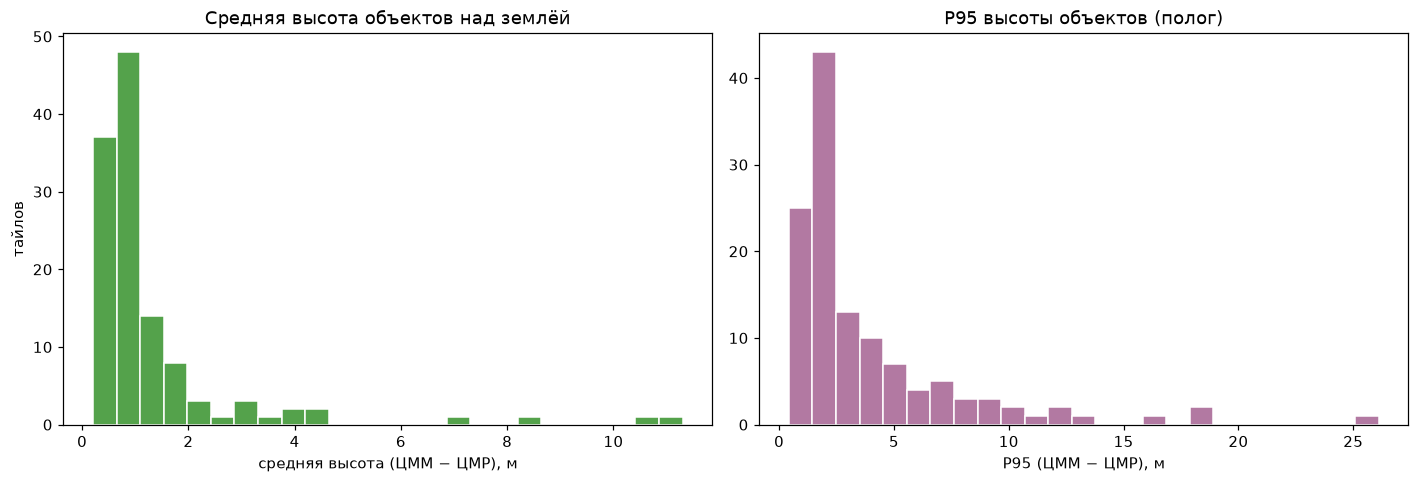

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(hdf['mean'], bins=25, color='#54A24B', edgecolor='white')
axes[0].set_xlabel('средняя высота (ЦММ − ЦМР), м'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Средняя высота объектов над землёй')
axes[1].hist(hdf['p95'], bins=25, color='#B279A2', edgecolor='white')
axes[1].set_xlabel('P95 (ЦММ − ЦМР), м')
axes[1].set_title('P95 высоты объектов (полог)')
plt.tight_layout(); plt.show()

## 11. Визуальный контроль на одном тайле

Живой прогон одного триплета с сохранением артефактов — чтобы убедиться, что
цифры выше соответствуют осмысленным растрам.

In [23]:
import rasterio, tempfile, shutil

DEMO_TILE = acc_dtm['rmse'].sort_values().index[len(acc_dtm) // 2]  # медианный по RMSE
tri = next(t for t in triplets if t.name == DEMO_TILE)
demo_dir = tempfile.mkdtemp(prefix='relief_bench_demo_')
rec = RB.run_triplet(tri, demo_dir, keep_outputs=True)
art = {a['layer']: a['path'] for a in rec['artifacts']}
print(f"Тайл {DEMO_TILE}: {rec['status']}, {rec['tile_duration_ms']} мс, "
      f"RMSE={rec['accuracy']['dtm']['rmse']:.3f} м")

ERROR 1: TIFFFetchDirectory:Sanity check on directory count failed, this is probably not a valid IFD offset
ERROR 1: TIFFReadDirectory:Failed to read directory at offset 1779530
ERROR 1: TIFFFetchDirectory:Sanity check on directory count failed, this is probably not a valid IFD offset
ERROR 1: TIFFReadDirectory:Failed to read directory at offset 1779530


Тайл P-42-053-016-e: done, 11380 мс, RMSE=0.069 м


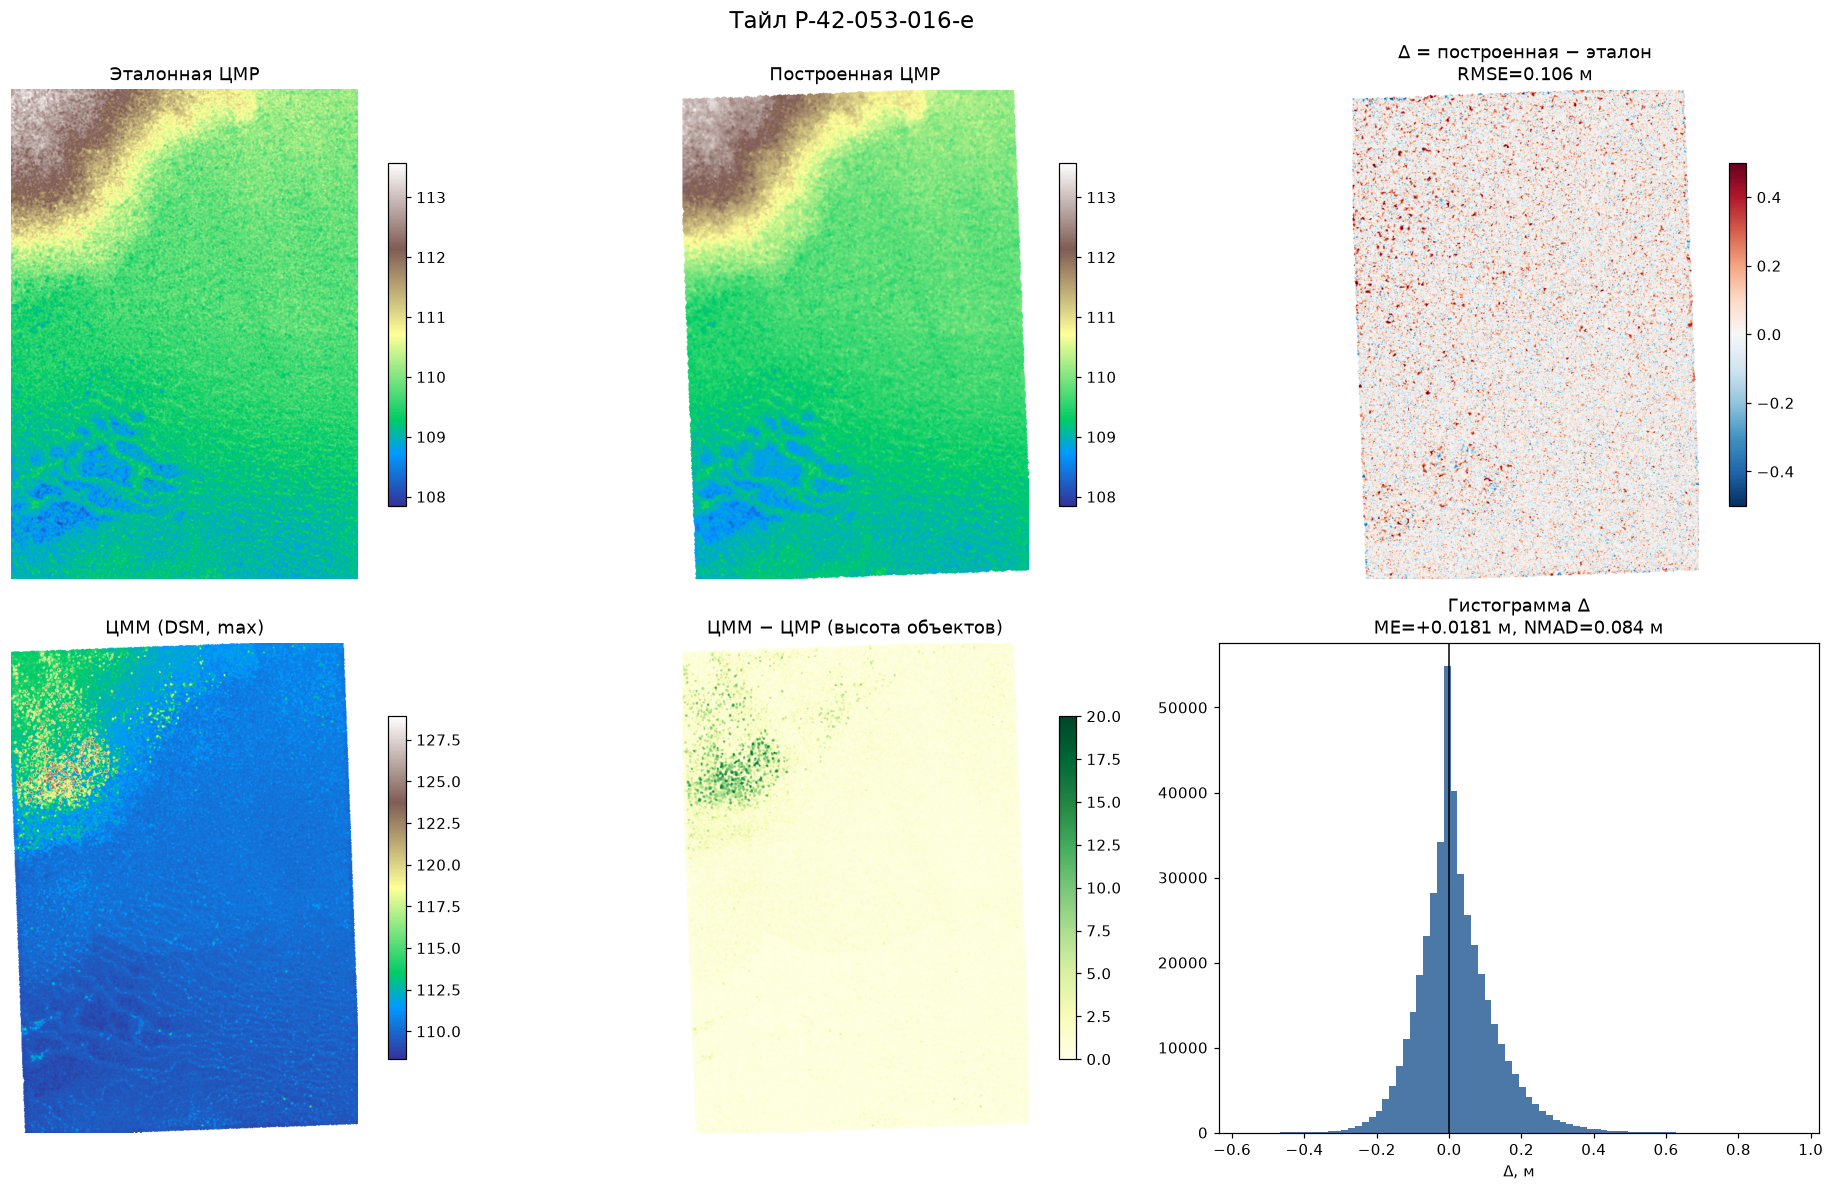

In [24]:
def read_raster(p):
    with rasterio.open(p) as s:
        a = s.read(1).astype(float)
        if s.nodata is not None:
            a = np.where(a == s.nodata, np.nan, a)
    return a

built, ref = RB.align_to_reference(art['dtm'], tri.ref)
diff = built - ref
dsm_a = RB.align_to_reference(art['dsm'], tri.ref)[0]

norm = mcolors.Normalize(vmin=np.nanmin(ref), vmax=np.nanmax(ref))
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, arr, title, kw in [
    (axes[0, 0], ref, 'Эталонная ЦМР', dict(cmap='terrain', norm=norm)),
    (axes[0, 1], built, 'Построенная ЦМР', dict(cmap='terrain', norm=norm)),
    (axes[0, 2], diff, f'Δ = построенная − эталон\nRMSE={np.sqrt(np.nanmean(diff**2)):.3f} м',
     dict(cmap='RdBu_r', vmin=-0.5, vmax=0.5)),
    (axes[1, 0], dsm_a, 'ЦММ (DSM, max)', dict(cmap='terrain')),
    (axes[1, 1], dsm_a - built, 'ЦММ − ЦМР (высота объектов)', dict(cmap='YlGn', vmin=0, vmax=20)),
]:
    im = ax.imshow(arr, **kw); ax.set_title(title, fontsize=12); ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=.7)

v = diff[np.isfinite(diff)]
axes[1, 2].hist(v, bins=80, color='#4C78A8', edgecolor='none')
axes[1, 2].axvline(0, color='k', lw=1)
axes[1, 2].set_title(f'Гистограмма Δ\nME={v.mean():+.4f} м, NMAD='
                     f'{1.4826*np.median(np.abs(v-np.median(v))):.3f} м', fontsize=12)
axes[1, 2].set_xlabel('Δ, м')

plt.suptitle(f'Тайл {DEMO_TILE}', fontsize=15)
plt.tight_layout(); plt.show()

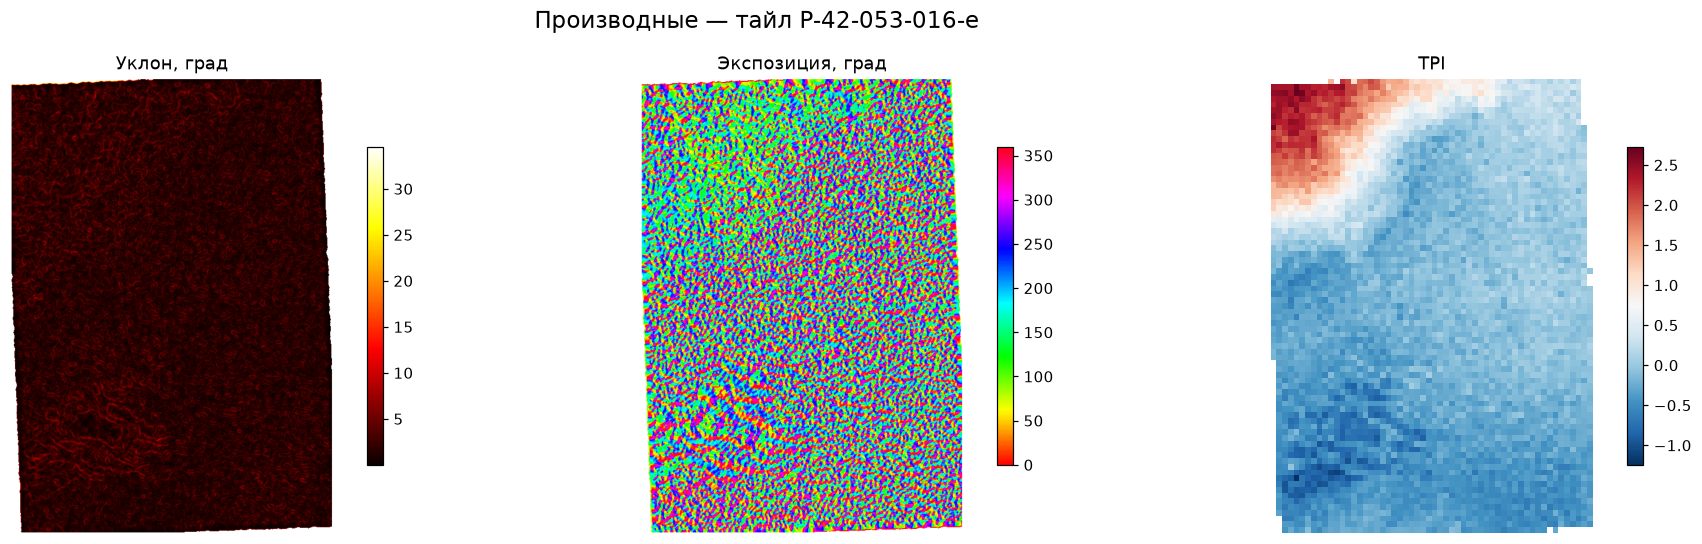

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, layer, title, cmap in [
    (axes[0], 'slope', 'Уклон, град', 'hot'),
    (axes[1], 'aspect', 'Экспозиция, град', 'hsv'),
    (axes[2], 'tpi', 'TPI', 'RdBu_r'),
]:
    if layer in art:
        im = ax.imshow(read_raster(art[layer]), cmap=cmap)
        ax.set_title(title, fontsize=12); ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=.7)
plt.suptitle(f'Производные — тайл {DEMO_TILE}', fontsize=15)
plt.tight_layout(); plt.show()

shutil.rmtree(demo_dir, ignore_errors=True)

## 12. Полная таблица результатов

Экспорт в CSV рядом с `results.jsonl`.

In [26]:
csv_path = RESULTS_DIR / 'benchmark_tiles.csv'
df.to_csv(csv_path, encoding='utf-8')
layer_csv = RESULTS_DIR / 'benchmark_by_layer.csv'
by_layer.to_csv(layer_csv, encoding='utf-8')
print('Сохранено:', csv_path, 'и', layer_csv)
df.round(4)

Сохранено: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results/benchmark_tiles.csv и /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results/benchmark_by_layer.csv


,points,area_km2,las_MB,ofp_MB,density_pts_m2,tile_s,total_s,rmse_m,mae_m,me_m,nmad_m,p95_m,измерено_%,rmse_всё_m,полнота_%,rel_rmse_%,ms_crop,ms_filter,ms_dtm,ms_dsm,ms_smooth,ms_slope,ms_aspect,ms_tpi,ms_contours,ms_tin,ms_heights,assess_ms,restore_ms,metrics_ms
tile,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
P-42-041-239-e,87500,0.4462,3.0,18.9,2.1122,1.643,2.0349,0.0563,0.0384,-0.0010,0.0364,0.1211,28.0547,0.0841,87.9436,0.0492,0,0,874,508,24,57,57,59,19,9,11,24.4251,18.6467,303.2449
P-42-041-239-f,93220,0.4462,3.2,19.2,2.1272,1.527,1.9095,0.0612,0.0420,0.0024,0.0405,0.1313,27.5369,0.0818,87.8378,0.0521,0,0,762,502,24,59,57,61,17,8,11,28.2696,20.6939,298.2106
P-42-041-239-g,1357824,0.4457,46.2,159.0,3.0484,17.659,18.4172,0.0646,0.0429,-0.0009,0.0397,0.1381,27.8386,0.3791,95.3925,0.0590,0,0,9504,7546,59,70,76,81,78,113,99,47.8324,98.3002,514.7425
P-42-041-239-h,1166858,0.4462,39.7,167.6,2.6175,14.877,15.5750,0.0597,0.0410,-0.0008,0.0397,0.1286,32.7953,0.0827,95.3013,0.0529,0,0,8218,6060,67,71,72,75,60,113,106,45.6460,91.0509,485.8622
P-42-041-240-d,85211,0.4462,2.9,22.3,1.8418,1.347,1.7350,0.0592,0.0406,0.0017,0.0393,0.1284,35.4310,0.0759,88.4724,0.0510,0,0,652,427,25,59,58,61,17,10,13,26.3320,19.1295,306.8624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P-42-053-128-e,1193099,0.4494,40.6,172.8,2.6595,15.712,16.4611,0.0704,0.0460,0.0021,0.0403,0.1522,19.9335,0.2848,95.0067,0.0735,0,0,8590,6559,58,71,73,74,72,98,84,50.5625,91.5240,502.9295
P-42-053-128-f,981695,0.4494,33.4,179.2,2.1873,12.715,13.4509,0.0626,0.0420,-0.0010,0.0387,0.1356,24.1880,0.1019,95.0942,0.0635,0,0,7040,5119,61,69,71,72,51,105,96,48.2808,80.3058,493.2353
P-42-053-128-g,997204,0.4494,33.9,168.0,2.3293,12.248,12.9858,0.0742,0.0484,0.0044,0.0432,0.1598,18.1669,1.2946,95.2200,0.0749,0,0,6620,5051,62,70,73,74,111,83,71,45.9738,85.9637,475.0186


---
## 13. Выводы

*(числа в тексте подставляются из ячейки ниже)*

In [27]:
lines = [
    'ПРОИЗВОДИТЕЛЬНОСТЬ',
    f'  Листов обработано:        {len(df)} из {len(triplets)}, {len(bad)} с ошибкой',
    f'  Объём:                    {df["points"].sum()/1e6:.1f} млн точек, '
    f'{df["area_km2"].sum():.2f} км², {df["las_MB"].sum()/1024:.2f} ГБ LAS',
    f'  Время на лист:            медиана {t.median():.2f} с, p95 {t.quantile(.95):.2f} с, '
    f'max {t.max():.2f} с',
    f'  Суммарное время:          {t.sum()/60:.1f} мин в один поток',
    f'  Пропускная способность:   {df["points"].sum()/t.sum()/1e6:.2f} млн точек/с, '
    f'{df["area_km2"].sum()/t.sum()*3600:.0f} км²/час (1 поток)',
    '  Самые дорогие шаги:       ' + ', '.join(
        f'{k} {v:.0f} %' for k, v in
        (100 * steps.sum() / steps.sum().sum()).sort_values(ascending=False).head(3).items()),
    f'  Масштабирование:          линейное по числу точек '
    f'({np.polyfit(df["points"]/1e6, t, 1)[0]:.2f} с на млн точек)',
    '',
    'ТОЧНОСТЬ ЦМР — ПО ИЗМЕРЕННЫМ ЯЧЕЙКАМ (см. ограничение методологии)',
    f'  RMSE:                     медиана {acc_dtm["rmse"].median():.3f} м, '
    f'p95 {acc_dtm["rmse"].quantile(.95):.3f} м, max {acc_dtm["rmse"].max():.3f} м',
    f'  MAE / NMAD:               {acc_dtm["mae"].median():.3f} м / '
    f'{acc_dtm["nmad"].median():.3f} м',
    f'  Систематический сдвиг ME: {acc_dtm["me"].median():+.4f} м — сдвига нет',
    f'  P95 |Δ|:                  {acc_dtm["p95"].median():.3f} м',
    f'  Критерий отн. RMSE < 5 %: {passed}/{len(acc_dtm)} листов, '
    f'максимум {acc_dtm["rel_rmse_pct"].max():.4f} %',
    '',
    'ЦЕНА ЗАПОЛНЕНИЯ ПУСТОТ',
    f'  Измерено ячеек:           медиана {acc_dtm["coverage_pct"].median():.1f} % листа',
    f'  RMSE со всеми ячейками:   медиана {acc_dtm["all_rmse"].median():.3f} м '
    f'(×{acc_dtm["all_rmse"].median()/acc_dtm["rmse"].median():.1f}), '
    f'p95 {acc_dtm["all_rmse"].quantile(.95):.3f} м',
    f'  Полнота растра:           медиана {acc_dtm["all_coverage_pct"].median():.1f} %, '
    f'min {acc_dtm["all_coverage_pct"].min():.1f} %, '
    f'ниже 50 % — {(acc_dtm["all_coverage_pct"] < 50).sum()} листов',
    '',
    'СГЛАЖИВАНИЕ И ЦММ',
    f'  Гаусс σ=2:                RMSE {acc_dtm["rmse"].median():.3f} → '
    f'{acc_smooth["rmse"].median():.3f} м '
    f'({100*(acc_smooth["rmse"].median()/acc_dtm["rmse"].median()-1):+.0f} %) — '
    f'плата за подавление шума перед расчётом производных',
    f'  ЦММ − ЦМР:                среднее {hdf["mean"].median():.2f} м, '
    f'P95 {hdf["p95"].median():.2f} м, max {hdf["max"].max():.2f} м '
    f'(высота объектов над землёй)',
]
print('\n'.join(lines))


ПРОИЗВОДИТЕЛЬНОСТЬ
  Листов обработано:        123 из 123, 0 с ошибкой
  Объём:                    77.7 млн точек, 55.19 км², 2.58 ГБ LAS
  Время на лист:            медиана 9.58 с, p95 15.34 с, max 657.84 с
  Суммарное время:          42.5 мин в один поток
  Пропускная способность:   0.03 млн точек/с, 78 км²/час (1 поток)
  Самые дорогие шаги:       dsm 76 %, dtm 22 %, tpi 0 %
  Масштабирование:          линейное по числу точек (19.94 с на млн точек)

ТОЧНОСТЬ ЦМР — ПО ИЗМЕРЕННЫМ ЯЧЕЙКАМ (см. ограничение методологии)
  RMSE:                     медиана 0.069 м, p95 0.087 м, max 0.092 м
  MAE / NMAD:               0.045 м / 0.040 м
  Систематический сдвиг ME: -0.0001 м — сдвига нет
  P95 |Δ|:                  0.152 м
  Критерий отн. RMSE < 5 %: 123/123 листов, максимум 0.0975 %

ЦЕНА ЗАПОЛНЕНИЯ ПУСТОТ
  Измерено ячеек:           медиана 19.9 % листа
  RMSE со всеми ячейками:   медиана 0.113 м (×1.6), p95 0.495 м
  Полнота растра:           медиана 94.2 %, min 42.9 %, ниже 50 % — 3 лист

### Что из этого следует

**Время.** Лист номенклатуры (~0.45 км², 0.1–2 млн точек) считается за секунды,
время растёт линейно по объёму облака. Почти всё уходит на два шага
растеризации — ЦМР и ЦММ; производные, векторизация и TIN на их фоне бесплатны.
Оценка производственного объёма: умножить «с на км²» на площадь съёмки и
разделить на число воркеров — листы независимы, сервис уже изолирует их.

**Точность построения.** Систематического сдвига нет, разброс — сантиметры,
приёмочный критерий выполняется с запасом в три порядка. Но это ошибка
*реконструкции*, а не *измерения*: абсолютные Z восстановлены из того же эталона.
Числа доказывают, что цепочка SMRF → растеризация → заполнение → сглаживание не
вносит заметных искажений, и ничего не говорят о точности ЦМР по реальным ВЛС.

**Цена интерполяции.** Ровно здесь разделение метрик окупается: по измеренным
ячейкам разброс RMSE узкий, по всем — растягивается в разы, и весь хвост
приходится на достроенные ячейки. Значит контролировать нужно две величины
независимо: RMSE (качество построения) и полноту (сколько площади вообще
покрыто). Полноту стоит вынести в приёмочные критерии наравне с RMSE — по RMSE
её дефицит не виден.

**Объём выдачи.** Основной вес даёт `ground_las`; если потребителю он не нужен,
`save_ground_las=False` сокращает выдачу в разы.

**Чего не хватает для полноценной валидации точности**

1. ВЛС с абсолютными Z вместо ТЛО — тогда сверка с эталоном станет независимой;
2. либо контрольные точки GNSS с известными отметками;
3. раздельная оценка по типу поверхности — под пологом леса SMRF ошибается
   сильнее всего, но на этом датасете это скрыто восстановлением Z.
